In [1]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

np.random.seed(42)

In [2]:
#Generate Large Synthetic Dataset

rows = 500

data = pd.DataFrame({
    "Production_Volume": np.random.randint(800, 3000, rows),
    "Energy_Consumption": np.random.randint(4000, 15000, rows),
    "Fuel_Usage": np.random.randint(200, 900, rows),
    "Transport_Distance": np.random.randint(100, 600, rows),
    "Raw_Material_Used": np.random.randint(600, 2000, rows),
})

data["CO2_Emission"] = (
    0.4 * data["Production_Volume"] +
    0.3 * data["Energy_Consumption"]/10 +
    0.2 * data["Fuel_Usage"] +
    0.1 * data["Transport_Distance"] +
    np.random.normal(0, 50, rows)
)

data.head()

,Production_Volume,Energy_Consumption,Fuel_Usage,Transport_Distance,Raw_Material_Used,CO2_Emission
0,1660,8175,378,128,1910,954.580815
1,2094,9348,381,494,1676,1199.616902
2,1930,13442,863,132,1927,1409.169968
3,1895,10190,224,233,1692,1129.157002
4,2438,5256,379,466,960,1216.228979


In [3]:
#Feature Engineering

data["Energy_per_Production"] = data["Energy_Consumption"] / data["Production_Volume"]

data.head()

,Production_Volume,Energy_Consumption,Fuel_Usage,Transport_Distance,Raw_Material_Used,CO2_Emission,Energy_per_Production
0,1660,8175,378,128,1910,954.580815,4.924699
1,2094,9348,381,494,1676,1199.616902,4.464183
2,1930,13442,863,132,1927,1409.169968,6.964767
3,1895,10190,224,233,1692,1129.157002,5.377309
4,2438,5256,379,466,960,1216.228979,2.155865


In [4]:
#Define Features & Target

X = data.drop("CO2_Emission", axis=1)
y = data["CO2_Emission"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)

Train Shape: (400, 6)


In [5]:
#Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
#Linear Regression Model

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("R2:", r2_score(y_test, lr_pred))

Linear Regression
MAE: 44.86820141169265
R2: 0.9559510020025671


In [7]:
#Random Forest with Hyperparameter Tuning

rf = RandomForestRegressor(random_state=42)

params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
}

grid = GridSearchCV(rf, params, cv=5, scoring="r2")
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

rf_pred = best_rf.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))

Best Parameters: {'max_depth': None, 'n_estimators': 100}
Random Forest MAE: 54.209756083309955
Random Forest R2: 0.9353050183909383


In [8]:
#Cross Validation Score

cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring="r2")
print("Cross Validation R2 Scores:", cv_scores)
print("Average CV Score:", np.mean(cv_scores))

Cross Validation R2 Scores: [0.94929156 0.93538601 0.94498018 0.91790648 0.91392508]
Average CV Score: 0.9322978630657127


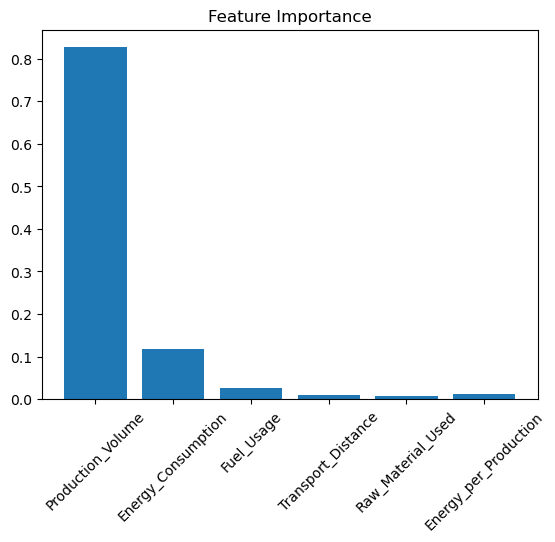

In [9]:
#Feature Importance (Important for Carbon Accounting)

importance = best_rf.feature_importances_
features = X.columns

plt.figure()
plt.bar(features, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

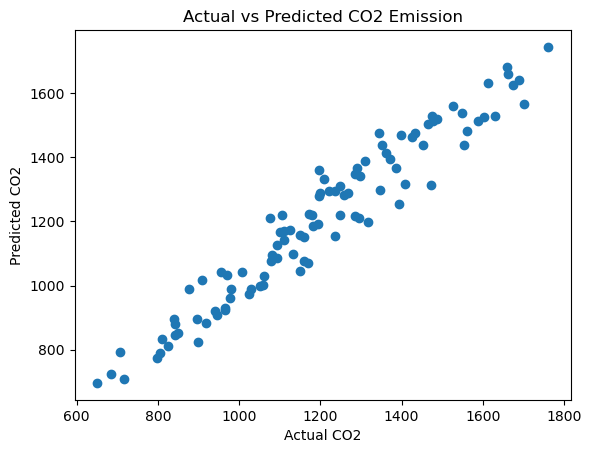

In [10]:
#Actual vs Predicted Graph

plt.figure()
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual CO2")
plt.ylabel("Predicted CO2")
plt.title("Actual vs Predicted CO2 Emission")
plt.show()

In [11]:
#Save Model (Professional Step)

joblib.dump(best_rf, "carbon_emission_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [12]:
#AI-Based Recommendation Engine

def carbon_recommendation(input_data, model, feature_names):
    
    prediction = model.predict(input_data)[0]
    
    print("Predicted CO2 Emission:", round(prediction, 2))
    print("\nAI Sustainability Recommendations:\n")
    
    # Convert to DataFrame
    input_df = pd.DataFrame(input_data, columns=feature_names)
    
    if input_df["Energy_Consumption"][0] > 10000:
        print("• Reduce energy consumption or switch to renewable energy.")
        
    if input_df["Fuel_Usage"][0] > 600:
        print("• Optimize fuel usage or adopt cleaner fuels.")
        
    if input_df["Transport_Distance"][0] > 400:
        print("• Improve supply chain efficiency to reduce transport emissions.")
        
    if input_df["Production_Volume"][0] > 2500:
        print("• Improve production efficiency to lower emission intensity.")
        
    print("\nEnd of AI Report")

In [13]:
#Test Recommendation Engine

new_industry = [[2600, 13000, 750, 500, 1800, 5]]  # include engineered feature if needed

carbon_recommendation(new_industry, best_rf, X.columns)

Predicted CO2 Emission: 1589.82

AI Sustainability Recommendations:

• Reduce energy consumption or switch to renewable energy.
• Optimize fuel usage or adopt cleaner fuels.
• Improve supply chain efficiency to reduce transport emissions.
• Improve production efficiency to lower emission intensity.

End of AI Report


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [14]:
import shap

In [16]:
#Create SHAP Explainer

explainer = shap.Explainer(best_rf, X_train)
shap_values = explainer(X_test)

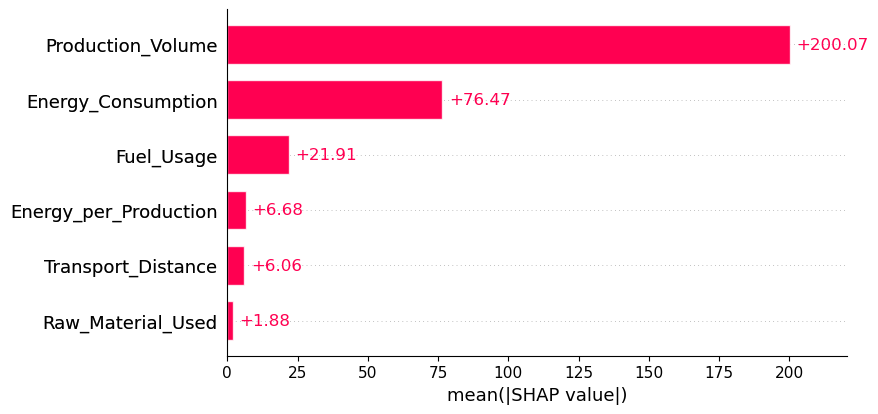

In [17]:
#Create SHAP Explainere

shap.plots.bar(shap_values)

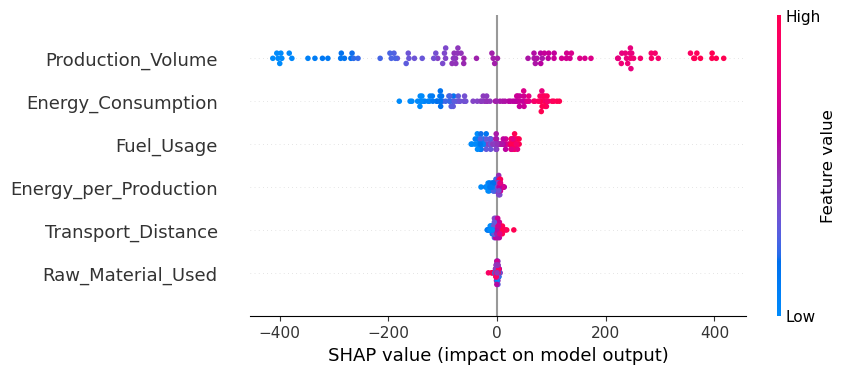

In [18]:
#Detailed Impact Visualization

shap.plots.beeswarm(shap_values)

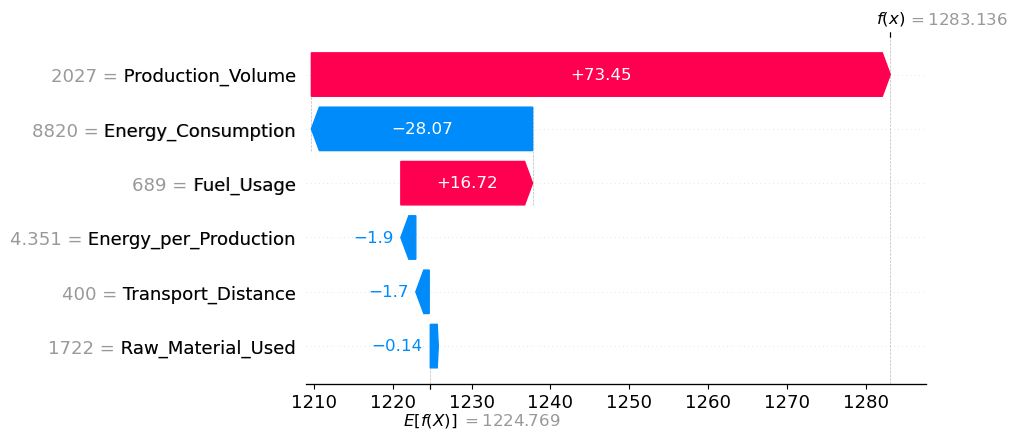

In [19]:
#Explain One Industry Prediction

shap.plots.waterfall(shap_values[0])